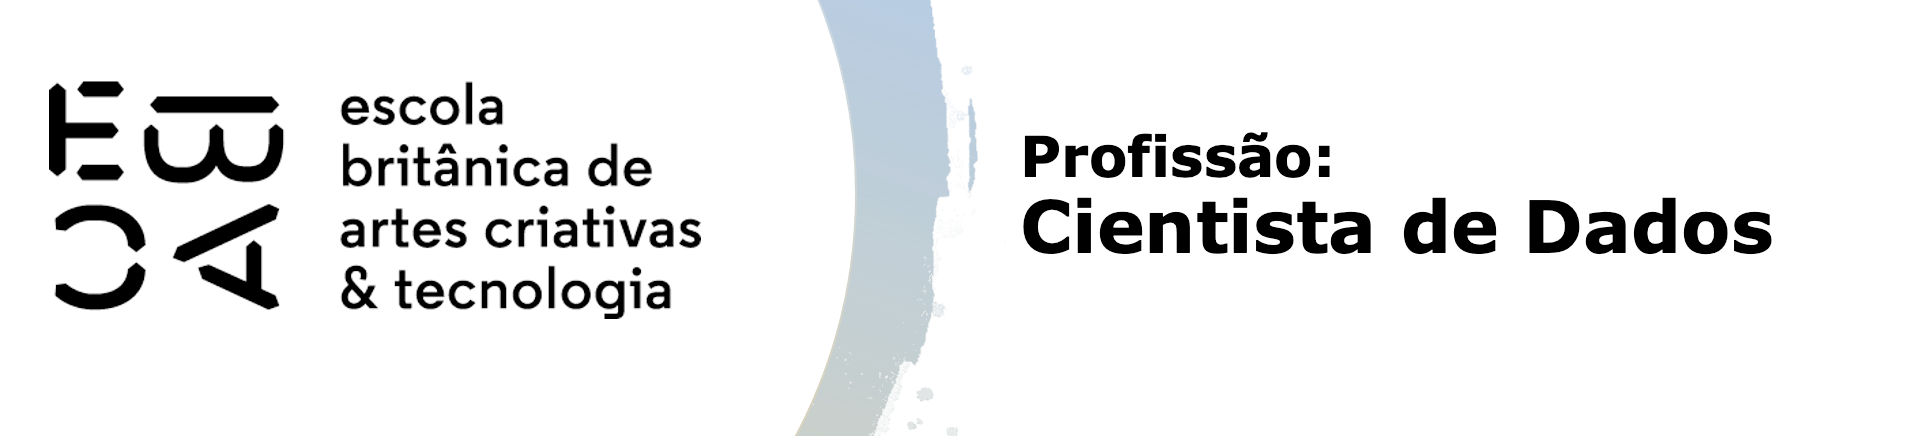

# Tarefa

Com base na tarefa realizada no módulo anterior, vamos fazer um diagnóstico do modelo.

Carregue a base ```previsao_de_renda2.csv```. Separe em uma base de treino e uma base de teste.

Vamos resgatar a melhor versão do modelod e previsão de renda que você fez para esta base. 

- Substitua missings pela média
- Rode novamente o modelo na base de treino (ou desenvolva-o caso não tenha o registro guardado). 

Este modelo deve prever a variável ```renda``` com base nas demais variáveis exceto ```data_ref``` e ```index```. Já vimos que a variável renda é melhor modelada com a transformação ```log()```, não se esqueça disso.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import patsy
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import mean_squared_error, r2_score
from scipy.interpolate import interp1d
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
df = pd.read_csv('previsao_de_renda_II.csv')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
0,2015-01-01,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47,16.717808,2.0,11138.14
1,2015-01-01,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30,9.600000,2.0,2424.81
2,2015-01-01,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28,8.208219,2.0,13749.66
3,2015-01-01,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44,1.301370,4.0,2361.84
4,2015-01-01,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33,1.254795,4.0,790.78


In [6]:
df.isnull().sum()

data_ref                      0
index                         0
sexo                          0
posse_de_veiculo              0
posse_de_imovel               0
qtd_filhos                    0
tipo_renda                    0
educacao                      0
estado_civil                  0
tipo_residencia               0
idade                         0
tempo_emprego            125760
qt_pessoas_residencia         0
renda                         0
dtype: int64

In [7]:
print(df['tempo_emprego'].mean())
df['tempo_emprego'].fillna(value=df['tempo_emprego'].mean(), inplace=True)
df.isna().sum()

7.746164800507006


data_ref                 0
index                    0
sexo                     0
posse_de_veiculo         0
posse_de_imovel          0
qtd_filhos               0
tipo_renda               0
educacao                 0
estado_civil             0
tipo_residencia          0
idade                    0
tempo_emprego            0
qt_pessoas_residencia    0
renda                    0
dtype: int64

In [8]:
df['data_ref']=pd.to_datetime(df['data_ref'])
df['log_renda'] = np.log(df.renda)
print(f'Primeiro data registrada no df: {df["data_ref"].min()}')
print(f'Última data registrada no df: {df["data_ref"].max()}')

Primeiro data registrada no df: 2015-01-01 00:00:00
Última data registrada no df: 2016-03-01 00:00:00


In [9]:
df['data_ref'].dt.to_period('M').unique()[-3:]

<PeriodArray>
['2016-01', '2016-02', '2016-03']
Length: 3, dtype: period[M]

Separando os dados em treino e teste:

In [11]:
df = df.sort_values('data_ref')

In [12]:
df_train = df[df['data_ref'] <= '2015-12-31']  # Até dezembro de 2015
df_test = df[df['data_ref'] >= '2016-01-01']   # A partir de janeiro de 2016
df_test.head(2)

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,log_renda
633328,2016-01-01,5766,F,S,N,0,Pensionista,Superior completo,Solteiro,Casa,63,7.746165,1.0,1364.05,7.218213
633329,2016-01-01,567,F,N,S,0,Pensionista,Médio,Casado,Casa,59,7.746165,2.0,4856.40,8.488053


In [13]:
df_train_b = df_train[['log_renda', 'posse_de_imovel', 'qtd_filhos', 'idade', 'tempo_emprego']]

In [14]:
lowess = sm.nonparametric.lowess(df_train_b['log_renda'], df_train_b['tempo_emprego'], frac=2/3)
f = interp1d(lowess[:, 0], lowess[:, 1], bounds_error=False)

df_train_b['tempo_emprego_lowess'] = f(df_train_b['tempo_emprego'])

X2 = patsy.dmatrices('''log_renda ~ 
                    + C(posse_de_imovel)
                    + qtd_filhos 
                    + idade
                    + tempo_emprego_lowess 
                    + 1''', df_train_b)

res = smf.ols(X2, data=df_train_b).fit()
res.summary()

C:\Users\gusta\AppData\Local\Temp\ipykernel_18600\2007998444.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_b['tempo_emprego_lowess'] = f(df_train_b['tempo_emprego'])


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_renda   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                 1.113e+05
Date:                Mon, 07 Jul 2025   Prob (F-statistic):               0.00
Time:                        12:40:31   Log-Likelihood:            -8.0368e+05
No. Observations:              600000   AIC:                         1.607e+06
Df Residuals:                  599995   BIC:                         1.607e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -0.0569      0.014     -3.962      0.000      -0.085      -0.029
C(posse_de_imovel)[T.S]     0.1802      0.003     70.260      0.000       0.175       0.185
qtd_filhos                  0.0062      0.002      3.561      0.000       0.003       0.010
idade                      -0.0040      0.000    -33.842      0.000      -0.004      -0.004
tempo_emprego_lowess        1.0106      0.002    653.091      0.000       1.008       1.014
==============================================================================
Omnibus:                      967.813   Durbin-Watson:                   1.253
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              859.945
Skew:                          -0.050   Prob(JB):                    1.84e-187
Kurtosis:                       2.844   Cond. No.                         558.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Verifique as suposições do modelo

Faça uma análise para avaliar as suposições básicas:

- Os resíduos desse modelo possuem distribuição Normal (ou algo próximo)?
- Verifique a independência dos resíduos
    - Faça um gráfico dos resíduos versus os valores preditos
    - Avalie se há padrões dos resíduos versus cada uma das variáveis do modelo
    - Avalie se o valor médio dos resíduos aparenta ter relação com o mês de referência
- Avalie se a variância da variável resposta parece ser conforme os valores previstos.

Você considera que as suposições estão atendidas? Há algum impacto em eventuais desvios?

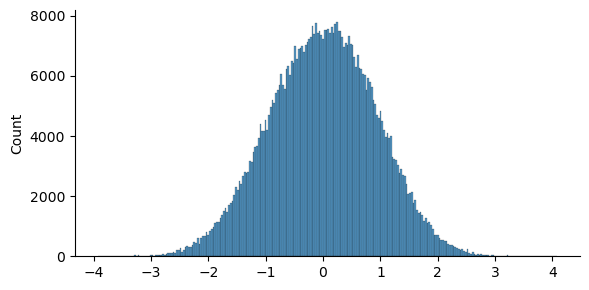

In [16]:
sns.displot(res.resid, height=3, aspect=2);

O formato do histograma se aproxima do esperado para uma distribuição normal, apresentando simetria em torno do valor zero e caudas sem indícios de assimetria acentuada ou curtose excessiva. Isso sugere que os resíduos estão aproximadamente distribuídos normalmente, o que atende a uma das premissas dos modelos lineares.


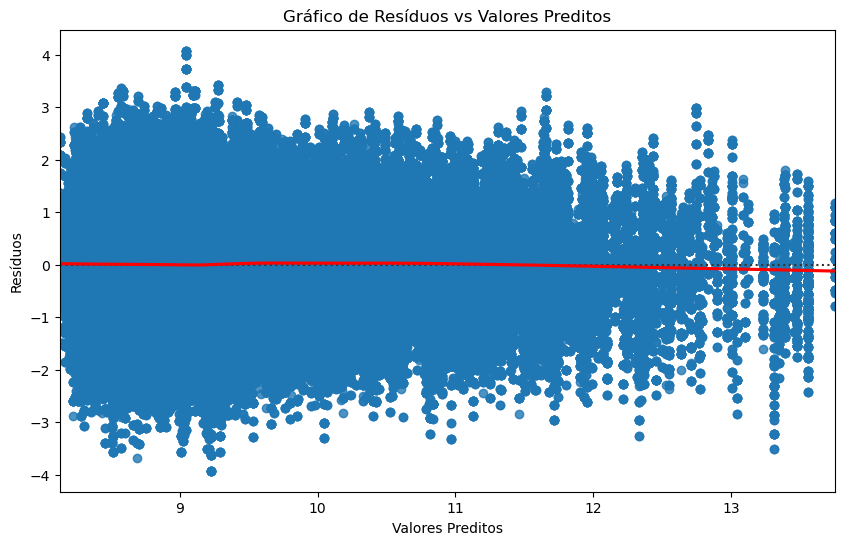

In [18]:
# Gráfico de resíduos x valores preditos
plt.figure(figsize=(10, 6))
sns.residplot(
    x=res.predict(),          # Valores preditos pelo modelo
    y=res.resid,              # Resíduos calculados
    lowess=True,              # Adiciona a linha suavizada (LOWESS)
    line_kws={'color': 'red'}  # Estilo da linha LOWESS
)
plt.title('Gráfico de Resíduos vs Valores Preditos')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.show()

Os resíduos de log_renda estão centrados em zero e, de forma geral, apresentam variância constante, com um leve aumento para valores preditos acima de 12 — o que pode indicar uma discreta heterocedasticidade. A linha de suavização (lowess) permanece próxima de zero, sugerindo bom ajuste do modelo.


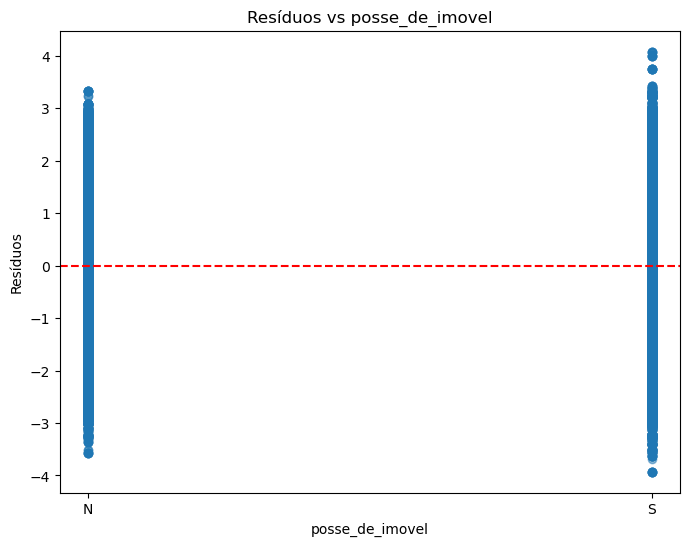

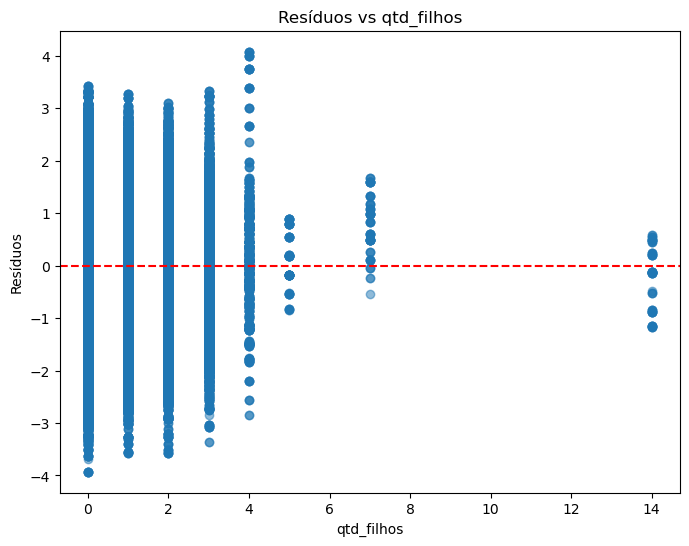

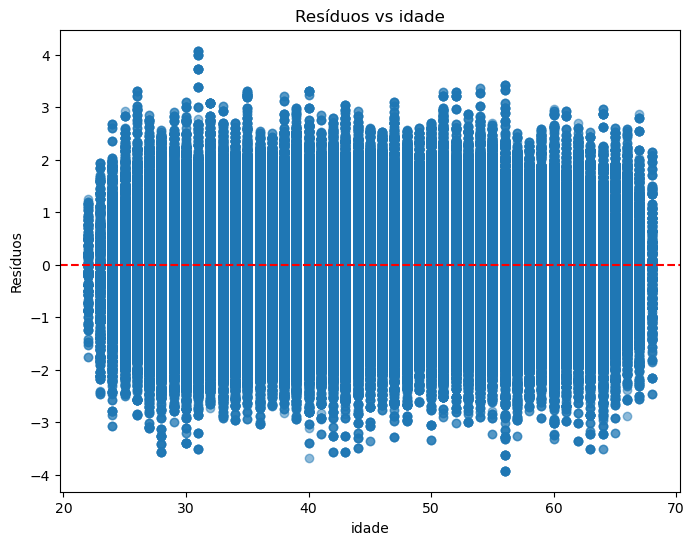

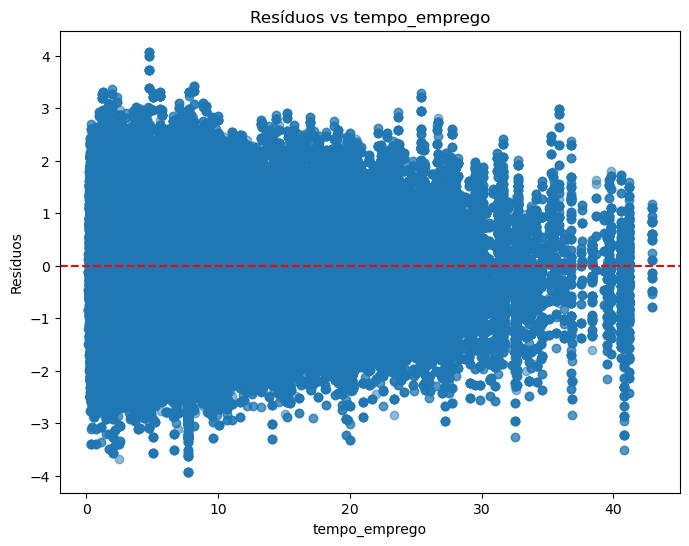

In [20]:
variaveis = ['posse_de_imovel', 'qtd_filhos', 'idade', 'tempo_emprego']

for var in variaveis:
    plt.figure(figsize=(8, 6))
    plt.scatter(df_train[var], res.resid, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel(var)
    plt.ylabel('Resíduos')
    plt.title(f'Resíduos vs {var}')
    plt.show()

Em modelos bem ajustados, espera-se que os resíduos estejam próximos de zero, distribuídos de forma aleatória e concentrados, em sua maioria, entre -3 e 3, sem evidência de padrões sistemáticos.

A variável idade segue esse comportamento de forma satisfatória, com poucos resíduos fora da faixa esperada, indicando que o modelo realiza boas previsões para essa variável.

Para tempo de emprego, o padrão também é razoável, embora se observe um leve afunilamento dos resíduos, possivelmente causado por outliers. Esse comportamento é aceitável, pois valores mais extremos, como longos períodos de emprego, são incomuns, mas plausíveis.

A variável quantidade de filhos apresenta um afunilamento mais acentuado, sugerindo que ela pode não estar contribuindo adequadamente para o modelo.

Já em posse de imóvel, há presença de outliers nos resíduos para ambas as classes (sim/não), o que pode indicar variabilidade interna dentro desses grupos.

Por fim, é importante destacar que, em um conjunto com mais de 500 mil registros, a presença de outliers é esperada e nem sempre indica erro nos dados — apenas valores que se distanciam da maioria.


## Outliers

Avalie os *studentized residuals*, verifique se há pontos que parecem ser discrepantes.

Avalie se há pontos influentes.

Índices de pontos discrepantes: (array([   109,    290,    361, ..., 599123, 599265, 599362], dtype=int64),)


C:\Users\gusta\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


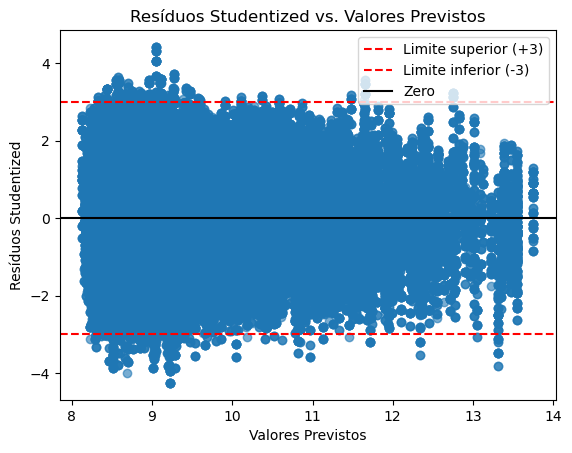

In [23]:
# Fórmula do modelo que estamos usando:
formula = '''log_renda ~ 
             C(posse_de_imovel) 
             + qtd_filhos 
             + idade 
             + tempo_emprego_lowess'''

# Gerando as matrizes X (variáveis independentes) e y (variável dependente):
y, X = patsy.dmatrices(formula, df_train_b)

# Ajustando o modelo de regressão
model = sm.OLS(y, X).fit()

# Obtendo os resíduos studentized:
influence = model.get_influence()
studentized_residuals = influence.resid_studentized_internal

# Identificando valores extremos (fora de [-3, 3]):
extremos = np.where((studentized_residuals > 3) | (studentized_residuals < -3))
print("Índices de pontos discrepantes:", extremos)

# Obtendo valores previstos (fitted values):
fitted_values = model.fittedvalues

# Visualizando os resíduos studentized:
plt.scatter(fitted_values, studentized_residuals, alpha=0.6)
plt.axhline(y=3, color='r', linestyle='--', label='Limite superior (+3)')
plt.axhline(y=-3, color='r', linestyle='--', label='Limite inferior (-3)')
plt.axhline(y=0, color='black', linestyle='-', label='Zero')
plt.xlabel("Valores Previstos")
plt.ylabel("Resíduos Studentized")
plt.title("Resíduos Studentized vs. Valores Previstos")
plt.legend()
plt.show()

Com o uso dos resíduos studentizados e a aplicação dos limites entre -3 e 3, o novo gráfico facilita a identificação visual dos outliers. Essa abordagem destaca de forma mais clara os pontos que se afastam do comportamento esperado. Além disso, foi criada a lista `extremos`, que armazena os índices das observações que ultrapassam esses limites, permitindo sua análise ou eventual tratamento posterior.


In [25]:
# Filtrando o DataFrame pelas linhas especificadas
df_train_b.iloc[extremos]

,log_renda,posse_de_imovel,qtd_filhos,idade,tempo_emprego,tempo_emprego_lowess
33242,6.328455,N,0,40,7.746165,9.230303
33497,5.893907,S,0,60,7.746165,9.230303
33494,7.889905,N,1,41,19.890411,10.937183
32843,6.339583,S,0,54,7.746165,9.230303
33006,6.270346,S,0,53,6.210959,9.060655
...,...,...,...,...,...,...
568606,6.017157,S,1,42,7.746165,9.230303
568193,10.084146,N,0,64,40.786301,13.476577
565845,5.401190,S,2,30,0.717808,8.406553
566906,6.213327,N,1,40,6.958904,9.137389


Entre os exemplos observados, há diferentes razões para que certas observações sejam classificadas como outliers. Algumas apresentam combinações incomuns, como idades elevadas com tempo de emprego curto ou, ao contrário, tempo de emprego muito alto em idades jovens, além de valores de log_renda significativamente altos. Por outro lado, alguns pontos identificados como outliers parecem estar dentro de padrões aceitáveis.

Para investigar o impacto desses pontos no modelo, identificamos 1.053 observações fora da faixa padrão e vamos removê-las para analisar como o desempenho do modelo se altera sem essas influências.


In [27]:
# Converter extremos em lista (se já não for)
extremos = np.array(extremos).flatten().tolist()

df_train_b_sem_outliers = df_train_b.drop(index=extremos)



# Verificação
print("Tamanho original:", df_train_b.shape[0])
print("Tamanho sem outliers:", df_train_b_sem_outliers.shape[0])


Tamanho original: 600000
Tamanho sem outliers: 598947


In [28]:
#Quinto modelo: Com Suavização LOWESS
X2 = patsy.dmatrices('''log_renda ~ 
                    + C(posse_de_imovel)
                    + qtd_filhos 
                    + idade
                    + tempo_emprego_lowess 
                    + 1''', df_train_b_sem_outliers)

res_teste_1 = smf.ols(X2, data=df_train_b_sem_outliers).fit()
res_teste_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_renda   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                 1.112e+05
Date:                Mon, 07 Jul 2025   Prob (F-statistic):               0.00
Time:                        12:50:07   Log-Likelihood:            -8.0210e+05
No. Observations:              598947   AIC:                         1.604e+06
Df Residuals:                  598942   BIC:                         1.604e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -0.0564      0.014     -3.928      0.000      -0.085      -0.028
C(posse_de_imovel)[T.S]     0.1799      0.003     70.107      0.000       0.175       0.185
qtd_filhos                  0.0063      0.002      3.628      0.000       0.003       0.010
idade                      -0.0040      0.000    -33.830      0.000      -0.004      -0.004
tempo_emprego_lowess        1.0106      0.002    652.694      0.000       1.008       1.014
==============================================================================
Omnibus:                      965.781   Durbin-Watson:                   1.253
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              858.103
Skew:                          -0.050   Prob(JB):                    4.63e-187
Kurtosis:                       2.844   Cond. No.                         558.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Não houve alteração no valor do R² após a remoção dos outliers, indicando que esses pontos não estavam distorcendo o ajuste do modelo. Portanto, optaremos por mantê-los, pois sua presença torna o modelo mais representativo da realidade.

A seguir, faremos a análise dos pontos influentes.
Obs.: Considerando o grande volume de observações, utilizaremos listas para identificar esses pontos, já que a visualização direta em gráficos fica prejudicada.

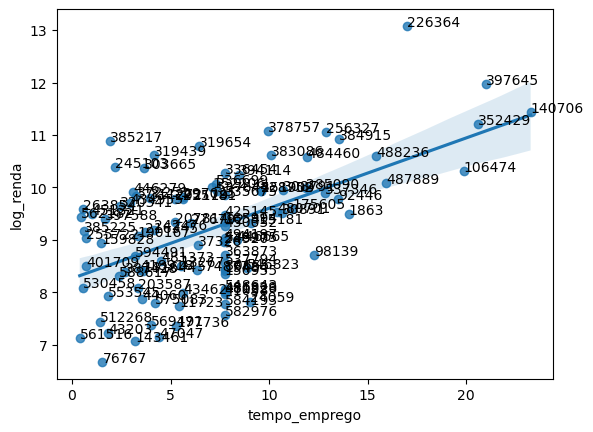

In [30]:
df_simplificado = df_train_b.sample(n=100, random_state=42)

fig, ax = plt.subplots()

sns.regplot(x='tempo_emprego', y='log_renda', data=df_simplificado, ax=ax)

for i in range(len(df_simplificado)):
    ax.annotate(str(df_simplificado.index[i]), 
                (df_simplificado.iloc[i]['tempo_emprego'], df_simplificado.iloc[i]['log_renda']))

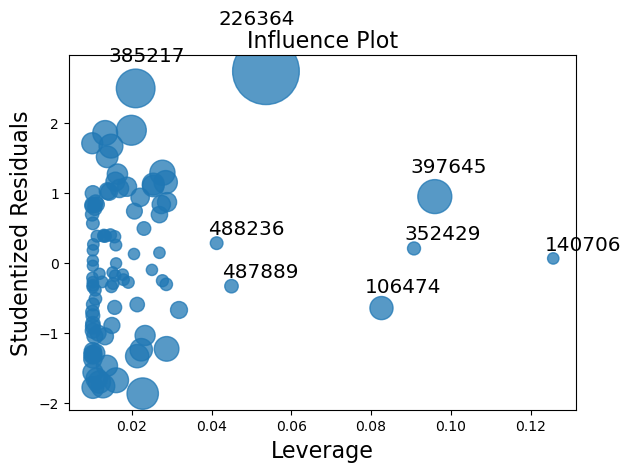

In [31]:
reg_simplificada = smf.ols('log_renda ~ tempo_emprego', data=df_simplificado).fit()

fig = sm.graphics.influence_plot(reg_simplificada, criterion="cooks")
fig.tight_layout(pad=1.0)

In [32]:
# Calculando a influência usando o método influence:
influence = res.get_influence()

# Obtendo Cook's Distance:
cooks_d = influence.cooks_distance[0]

# Número de observações:
n = len(df_train_b)

# Limite para Cook's Distance (baseado na regra comum):
cooks_threshold = 4 / n

# Identificar pontos influentes com base no Cook's Distance:
pontos_influentes_cooks = np.where(cooks_d > cooks_threshold)[0]

In [33]:
df_train_b.iloc[pontos_influentes_cooks]

,log_renda,posse_de_imovel,qtd_filhos,idade,tempo_emprego,tempo_emprego_lowess
33307,6.890029,N,0,53,7.746165,9.230303
33315,7.173322,N,0,62,7.746165,9.230303
33381,6.615262,S,1,28,1.758904,8.545387
33383,8.750271,N,1,42,21.465753,11.132595
33357,12.970504,S,0,62,42.906849,13.729382
...,...,...,...,...,...,...
566736,7.583166,S,3,33,3.060274,8.718705
566719,7.476857,N,3,29,5.298630,8.974570
566628,9.818323,N,0,62,26.931507,11.801865
566610,10.824706,S,0,50,30.619178,12.250394


In [34]:
#Deixando so extremos em formato de lista para casar:
pontos_influentes = np.array(pontos_influentes_cooks).flatten().tolist()

# Removendo os índices dos outliers do DataFrame:
df_train_b_sem_pi = df_train_b.drop(index=pontos_influentes)

In [35]:
X2 = patsy.dmatrices('''log_renda ~ 
                    + C(posse_de_imovel)
                    + qtd_filhos 
                    + idade
                    + tempo_emprego_lowess 
                    + 1''', df_train_b_sem_pi)

res_teste_2 = smf.ols(X2, data=df_train_b_sem_pi).fit()
res_teste_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_renda   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                 1.070e+05
Date:                Mon, 07 Jul 2025   Prob (F-statistic):               0.00
Time:                        12:50:11   Log-Likelihood:            -7.6311e+05
No. Observations:              571496   AIC:                         1.526e+06
Df Residuals:                  571491   BIC:                         1.526e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -0.0558      0.015     -3.810      0.000      -0.085      -0.027
C(posse_de_imovel)[T.S]     0.1801      0.003     68.820      0.000       0.175       0.185
qtd_filhos                  0.0066      0.002      3.697      0.000       0.003       0.010
idade                      -0.0040      0.000    -33.098      0.000      -0.004      -0.004
tempo_emprego_lowess        1.0111      0.002    640.338      0.000       1.008       1.014
==============================================================================
Omnibus:                      855.406   Durbin-Watson:                   1.263
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              768.097
Skew:                          -0.051   Prob(JB):                    1.62e-167
Kurtosis:                       2.852   Cond. No.                         558.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Observamos um aumento no R² de 0,2% após a remoção das observações. Porém, esse ganho modesto não justifica a exclusão desses dados, pois tal remoção pode comprometer a capacidade de generalização do modelo.

## Multicolinearidade

Avalie se há questões relacionadas a multicolinearidade através de pelo menos:

- Matriz de correlação de Spearman
- VIF

Tanto a análise da matriz de correlação quanto o cálculo do VIF requerem variáveis numéricas. Por isso, iniciaremos convertendo a variável posse_de_imovel para formato binário, permitindo sua inclusão nas análises de multicolinearidade.

In [39]:
#Não vira 0 e Sim vira 1:
df_train_b['posse_de_imovel']= df_train_b['posse_de_imovel'].map({'N': 0, 'S': 1})

C:\Users\gusta\AppData\Local\Temp\ipykernel_18600\3823401811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_b['posse_de_imovel']= df_train_b['posse_de_imovel'].map({'N': 0, 'S': 1})


In [40]:
#criando um novo df em que temos apenas variáveis numéricas:
num_train_b= df_train_b[['posse_de_imovel', 'qtd_filhos', 'idade', 'tempo_emprego_lowess']]
num_train_b.head()

,posse_de_imovel,qtd_filhos,idade,tempo_emprego_lowess
0,0,0,47,10.526933
33328,0,0,26,8.623888
33329,0,0,40,8.693557
33330,0,0,33,9.622570
33331,1,0,25,9.069412


In [41]:
#matriz de correlação entre as variáveis explicativas:
num_train_b.corr(method='spearman')

,posse_de_imovel,qtd_filhos,idade,tempo_emprego_lowess
posse_de_imovel,1.000000,-0.014131,0.130211,0.014221
qtd_filhos,-0.014131,1.000000,-0.415384,-0.090583
idade,0.130211,-0.415384,1.000000,0.301418
tempo_emprego_lowess,0.014221,-0.090583,0.301418,1.000000


A maior correlação observada foi entre as variáveis idade e tempo de emprego. Para confirmar a presença de multicolinearidade, utilizaremos o VIF (Variance Inflation Factor) — uma métrica aplicada em regressão para quantificar a intensidade da multicolinearidade entre variáveis independentes.

In [43]:
vars_vif = pd.DataFrame() 
vars_vif["VIF Factor"] = [vif(num_train_b, i) for i in range(num_train_b.shape[1])]
vars_vif["Feature"] = num_train_b.columns

vars_vif.round(2)

,VIF Factor,Feature
0,3.08,posse_de_imovel
1,1.52,qtd_filhos
2,19.81,idade
3,21.92,tempo_emprego_lowess


O VIF reforça a presença de multicolinearidade entre as variáveis idade e tempo de emprego, conforme já indicado pela matriz de correlação.

## Ajustes

Faça os ajustes que julgar necessários no modelo e compare as métricas de desempenho do modelo original e ajustado na base de testes.

A primeira abordagem será remover a variável idade, mantendo apenas tempo_emprego no modelo, e então reavaliar os resultados.

In [47]:
#modelo ajustado 1: retiramos idade:
X1 = patsy.dmatrices('''log_renda ~ 
                    + C(posse_de_imovel)
                    + qtd_filhos 
                    + tempo_emprego_lowess 
                    + 1''', df_train_b)

res1 = smf.ols(X1, data=df_train_b).fit()
res1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_renda   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                 1.478e+05
Date:                Mon, 07 Jul 2025   Prob (F-statistic):               0.00
Time:                        12:50:15   Log-Likelihood:            -8.0425e+05
No. Observations:              600000   AIC:                         1.609e+06
Df Residuals:                  599996   BIC:                         1.609e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -0.1234      0.014     -8.674      0.000      -0.151      -0.096
C(posse_de_imovel)[T.1]     0.1680      0.003     66.090      0.000       0.163       0.173
qtd_filhos                  0.0279      0.002     17.214      0.000       0.025       0.031
tempo_emprego_lowess        0.9988      0.002    662.033      0.000       0.996       1.002
==============================================================================
Omnibus:                      947.422   Durbin-Watson:                   1.254
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              843.296
Skew:                          -0.050   Prob(JB):                    7.60e-184
Kurtosis:                       2.846   Cond. No.                         113.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
#modelo ajustado 2: só com tempo_emprego:
X1 = patsy.dmatrices('''log_renda ~ 
                    tempo_emprego_lowess 
                    + 1''', df_train_b)
res2 = smf.ols(X1, data=df_train_b).fit()
res2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_renda   R-squared:                       0.421
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                 4.354e+05
Date:                Mon, 07 Jul 2025   Prob (F-statistic):               0.00
Time:                        12:50:15   Log-Likelihood:            -8.0656e+05
No. Observations:              600000   AIC:                         1.613e+06
Df Residuals:                  599998   BIC:                         1.613e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0169      0.014      1.197      0.231      -0.011       0.044
tempo_emprego_lowess     0.9971      0.002    659.838      0.000       0.994       1.000
==============================================================================
Omnibus:                      868.551   Durbin-Watson:                   1.260
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              774.847
Skew:                          -0.047   Prob(JB):                    5.55e-169
Kurtosis:                       2.851   Cond. No.                         111.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [49]:
#modelo ajustado 3: sem tempo_emprego:
X1 = patsy.dmatrices('''log_renda ~ 
                    + C(posse_de_imovel)
                    + qtd_filhos 
                    + idade
                    + 1''', df_train_b)

res3 = smf.ols(X1, data=df_train_b).fit()
res3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_renda   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     3673.
Date:                Mon, 07 Jul 2025   Prob (F-statistic):               0.00
Time:                        12:50:18   Log-Likelihood:            -9.6478e+05
No. Observations:              600000   AIC:                         1.930e+06
Df Residuals:                  599996   BIC:                         1.930e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   8.5867      0.007   1181.918      0.000       8.572       8.601
C(posse_de_imovel)[T.1]     0.1263      0.003     37.678      0.000       0.120       0.133
qtd_filhos                  0.0330      0.002     14.487      0.000       0.029       0.037
idade                       0.0135      0.000     89.621      0.000       0.013       0.014
==============================================================================
Omnibus:                    24370.821   Durbin-Watson:                   1.565
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            29820.915
Skew:                           0.456   Prob(JB):                         0.00
Kurtosis:                       3.601   Cond. No.                         214.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

De fato, observa-se que a variável tempo_emprego contribui de forma mais significativa para a explicação da variável log_renda, indicando que sua permanência no modelo é mais adequada.